Carga de datos

In [2]:
import pandas as pd
import io
from google.colab import files

# 1. Cargar archivo
uploaded = files.upload()

# 2. Lectura a Dataframe
nombre_archivo = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[nombre_archivo]))

# 3. Verificacion
print(f"Dimensiones del dataset: {df.shape[0]} filas y {df.shape[1]} columnas.")
df.head()

df.info()

print("\nDistribución de la variable objetivo:")
print(df['Evasion'].value_counts(normalize=True) * 100)

Saving datos_telecom_limpios.csv to datos_telecom_limpios.csv
Dimensiones del dataset: 7043 filas y 22 columnas.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID_Cliente                 7043 non-null   object 
 1   Evasion                    7043 non-null   int64  
 2   Genero                     7043 non-null   object 
 3   Adulto_Mayor               7043 non-null   int64  
 4   Tiene_Pareja               7043 non-null   int64  
 5   Tiene_Dependientes         7043 non-null   int64  
 6   Meses_Permanencia          7043 non-null   int64  
 7   Servicio_Telefonico        7043 non-null   int64  
 8   phone.MultipleLines        7043 non-null   object 
 9   internet.InternetService   7043 non-null   object 
 10  internet.OnlineSecurity    7043 non-null   object 
 11  internet.OnlineBackup      7043 non-null   obje

Eliminacion de columnas irrelevantes

In [11]:
#Crear copia para mantener la integridad original de los datos
df_modelo = df.copy()

#Definir columnas irrelevantes
columnas_irrelevantes = ['ID_Cliente', 'Cargos_Diarios']

# Eliminamos las columnas
df_modelo = df_modelo.drop(columns=columnas_irrelevantes)

Encoding

In [12]:
df_final_ml = pd.get_dummies(df_modelo, drop_first=True)

df_final_ml.head()

,Evasion,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Meses_Permanencia,Servicio_Telefonico,Cargos_Mensuales,Cargos_Totales,Genero_male,phone.MultipleLines_no phone service,...,internet.StreamingTV_no internet service,internet.StreamingTV_yes,internet.StreamingMovies_no internet service,internet.StreamingMovies_yes,Tipo_Contrato_one year,Tipo_Contrato_two year,account.PaperlessBilling_yes,account.PaymentMethod_credit card (automatic),account.PaymentMethod_electronic check,account.PaymentMethod_mailed check
0,0,0,1,1,9,1,65.6,593.30,False,False,...,False,True,False,False,True,False,True,False,False,True
1,0,0,0,0,9,1,59.9,542.40,True,False,...,False,False,False,True,False,False,False,False,False,True
2,1,0,0,0,4,1,73.9,280.85,True,False,...,False,False,False,False,False,False,True,False,True,False
3,1,1,1,0,13,1,98.0,1237.85,True,False,...,False,True,False,True,False,False,True,False,True,False
4,1,1,1,0,3,1,83.9,267.40,False,False,...,False,True,False,False,False,False,True,False,False,True


Verificación de la Proporción de Cancelación (Churn)

In [13]:
# Contar clientes: 0 = No se fue, 1 = Se fue
conteo_clases = df_final_ml['Evasion'].value_counts()
proporcion_clases = df_final_ml['Evasion'].value_counts(normalize=True) * 100

print("Conteo absoluto de clientes:")
print(conteo_clases)

print("\nProporción porcentual:")
print(proporcion_clases)



Conteo absoluto de clientes:
Evasion
0    5174
1    1869
Name: count, dtype: int64

Proporción porcentual:
Evasion
0    73.463013
1    26.536987
Name: proportion, dtype: float64


Graficas

/tmp/ipykernel_327/1979821096.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Evasion', data=df_final_ml, palette='viridis')


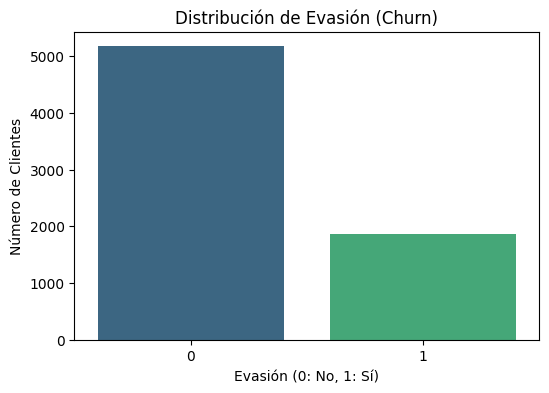

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='Evasion', data=df_final_ml, palette='viridis')
plt.title('Distribución de Evasión (Churn)')
plt.xlabel('Evasión (0: No, 1: Sí)')
plt.ylabel('Número de Clientes')
plt.show()

Balanceo de Clases

In [15]:
from imblearn.over_sampling import SMOTE

X = df_final_ml.drop('Evasion', axis=1)
y = df_final_ml['Evasion']

# Configurar SMOTE
smt = SMOTE(random_state=42)

# Aplicar balanceo
X_res, y_res = smt.fit_resample(X, y)

# Verificar nuevo balance
print("Distribución después de SMOTE:")
print(y_res.value_counts(normalize=True) * 100)

Distribución después de SMOTE:
Evasion
0    50.0
1    50.0
Name: proportion, dtype: float64


Normalización o Estandarización

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.3, random_state=42)

print(f"Variables: X_train tiene {X_train.shape[0]} muestras.")

✅ Variables definidas: X_train tiene 7243 muestras.


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Análisis de Correlación

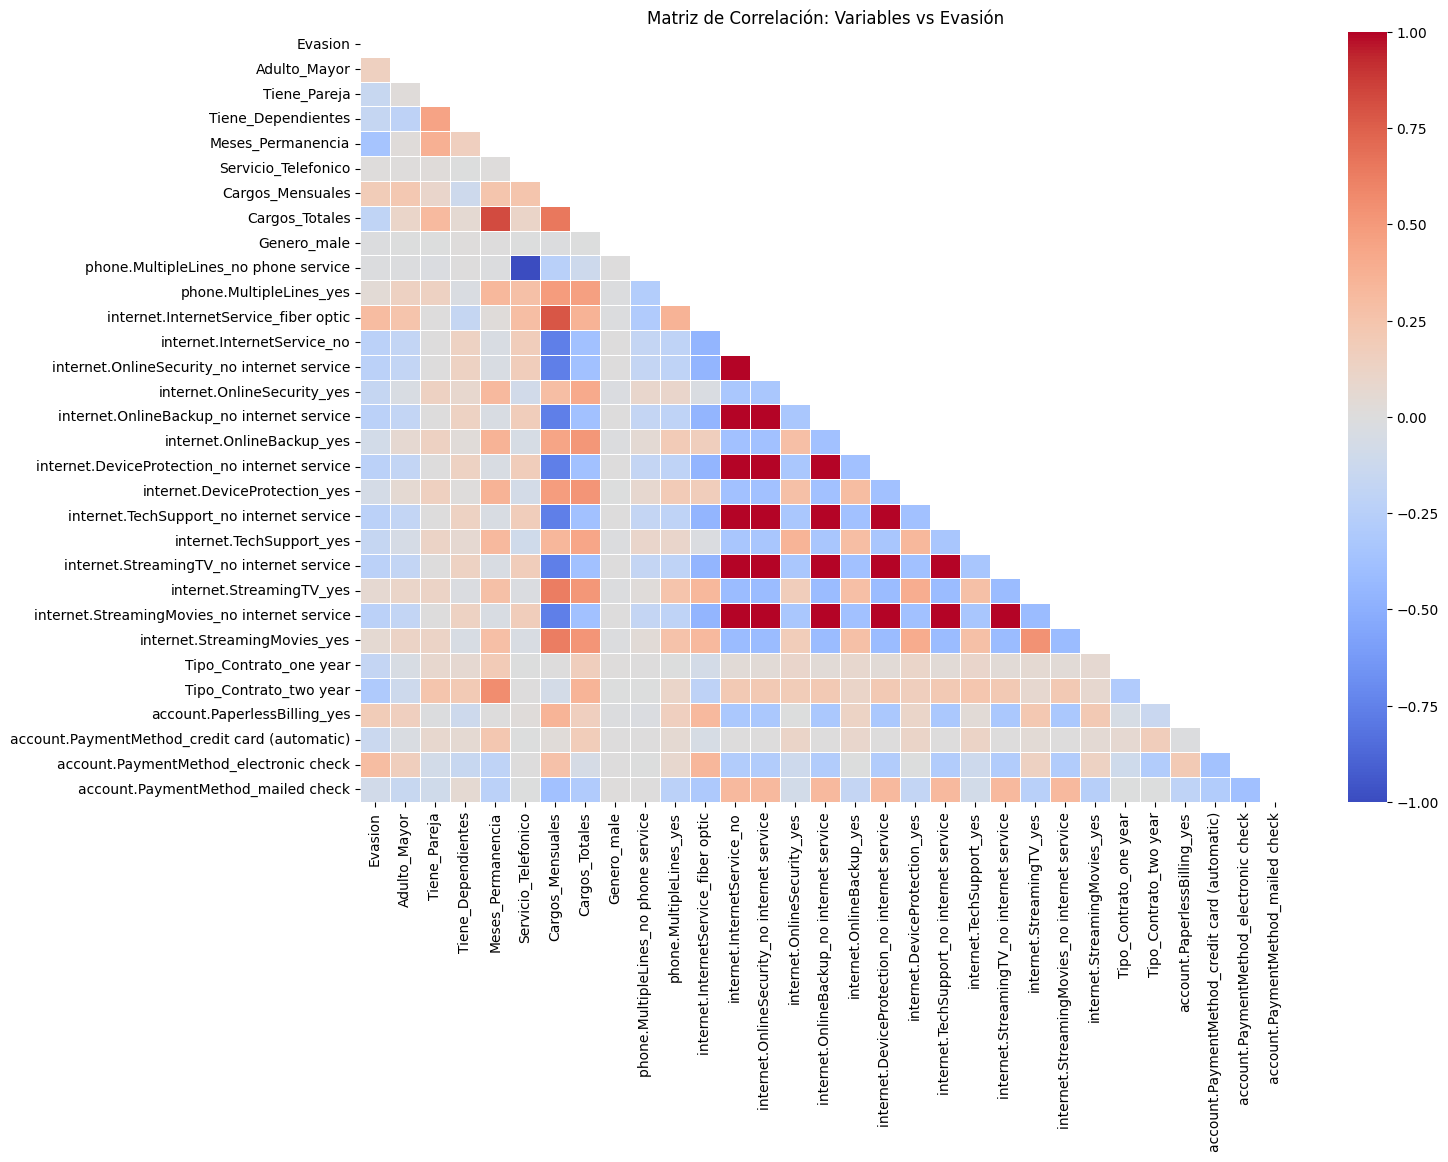

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

corr_matrix = df_final_ml.corr()

plt.figure(figsize=(15, 10))


mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix,
            mask=mask,
            annot=False,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5)

plt.title('Matriz de Correlación: Variables vs Evasión')
plt.show()

In [20]:
churn_corr = df_final_ml.corr()['Evasion'].sort_values(ascending=False)

print("--- 5 Variables que más impulsan la evasión ---")
print(churn_corr.head(6))

print("\n--- 5 Variables que más ayudan a la retención ---")
print(churn_corr.tail(5))

--- Top 5 Variables que MÁS impulsan la Evasión ---
Evasion                                   1.000000
internet.InternetService_fiber optic      0.308020
account.PaymentMethod_electronic check    0.301919
Cargos_Mensuales                          0.193356
account.PaperlessBilling_yes              0.191825
Adulto_Mayor                              0.150889
Name: Evasion, dtype: float64

--- Top 5 Variables que MÁS ayudan a la Retención ---
internet.DeviceProtection_no internet service   -0.227890
internet.StreamingMovies_no internet service    -0.227890
internet.TechSupport_no internet service        -0.227890
Tipo_Contrato_two year                          -0.302253
Meses_Permanencia                               -0.352229
Name: Evasion, dtype: float64


Análisis Dirigido

/tmp/ipykernel_327/1043538310.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Evasion', y='Meses_Permanencia', data=df, palette='magma')


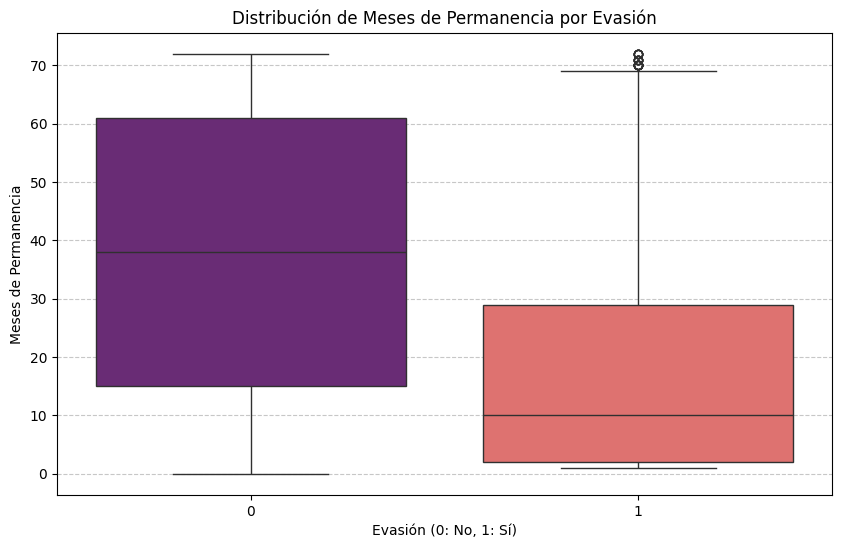

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(x='Evasion', y='Meses_Permanencia', data=df, palette='magma')
plt.title('Distribución de Meses de Permanencia por Evasión')
plt.xlabel('Evasión (0: No, 1: Sí)')
plt.ylabel('Meses de Permanencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

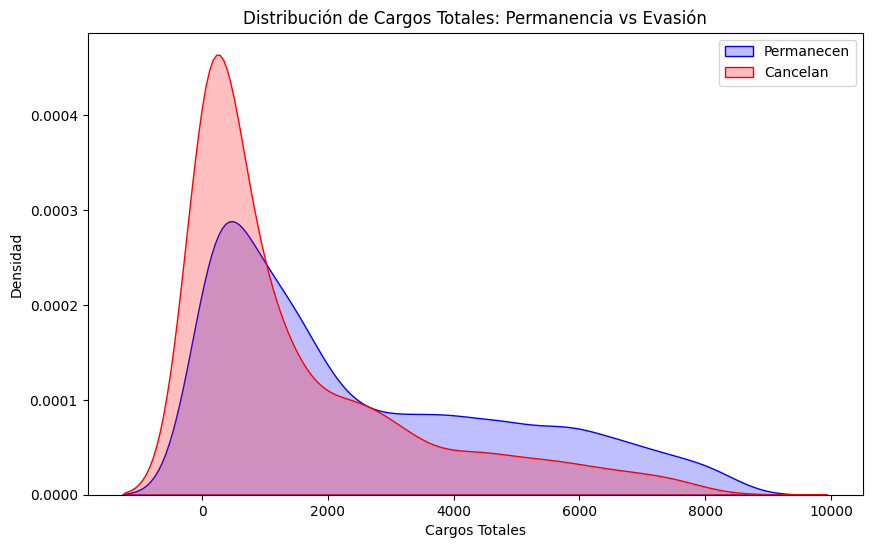

In [22]:
plt.figure(figsize=(10, 6))

sns.kdeplot(df[df['Evasion'] == 0]['Cargos_Totales'], label='Permanecen', fill=True, color='blue')
sns.kdeplot(df[df['Evasion'] == 1]['Cargos_Totales'], label='Cancelan', fill=True, color='red')

plt.title('Distribución de Cargos Totales: Permanencia vs Evasión')
plt.xlabel('Cargos Totales')
plt.ylabel('Densidad')

plt.legend()
plt.show()

Separacion de datos

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_res,
    y_res,
    test_size=0.30,
    random_state=42
)

Creación de Modelos

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

modelo_logistico = LogisticRegression(random_state=42)

modelo_logistico.fit(X_train_scaled, y_train)

y_pred_log = modelo_logistico.predict(X_test_scaled)

print("Resultados regresion: Logica")
print(classification_report(y_test, y_pred_log))

Resultados regresion: Logica
              precision    recall  f1-score   support

           0       0.82      0.80      0.81      1588
           1       0.80      0.82      0.81      1517

    accuracy                           0.81      3105
   macro avg       0.81      0.81      0.81      3105
weighted avg       0.81      0.81      0.81      3105



In [25]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)

modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)

print("Resultados: Ramdon Forest")
print(classification_report(y_test, y_pred_rf))

Resultados: Ramdon Forest
              precision    recall  f1-score   support

           0       0.85      0.84      0.84      1588
           1       0.83      0.84      0.84      1517

    accuracy                           0.84      3105
   macro avg       0.84      0.84      0.84      3105
weighted avg       0.84      0.84      0.84      3105



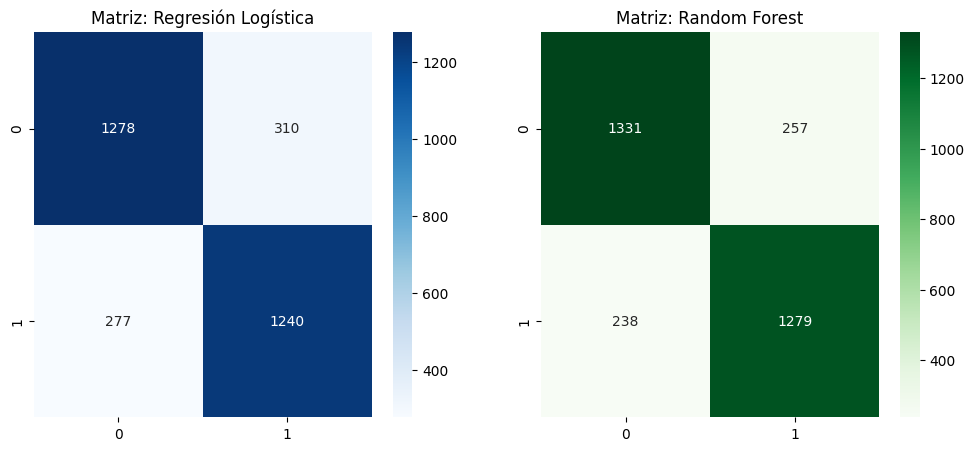

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', ax=ax[0], cmap='Blues')
ax[0].set_title('Matriz: Regresión Logística')

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', ax=ax[1], cmap='Greens')
ax[1].set_title('Matriz: Random Forest')

plt.show()

Evaluación de los Modelos

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd

def evaluar_modelo(nombre, y_real, y_pred):
    return {
        "Modelo": nombre,
        "Exactitud": accuracy_score(y_real, y_pred),
        "Precisión": precision_score(y_real, y_pred),
        "Recall": recall_score(y_real, y_pred),
        "F1-Score": f1_score(y_real, y_pred)
    }

metricas_log = evaluar_modelo("Regresión Logística", y_test, y_pred_log)
metricas_rf = evaluar_modelo("Random Forest", y_test, y_pred_rf)

df_metricas = pd.DataFrame([metricas_log, metricas_rf])
display(df_metricas)

,Modelo,Exactitud,Precisión,Recall,F1-Score
0,Regresión Logística,0.81095,0.800000,0.817403,0.808608
1,Random Forest,0.84058,0.832682,0.843111,0.837864


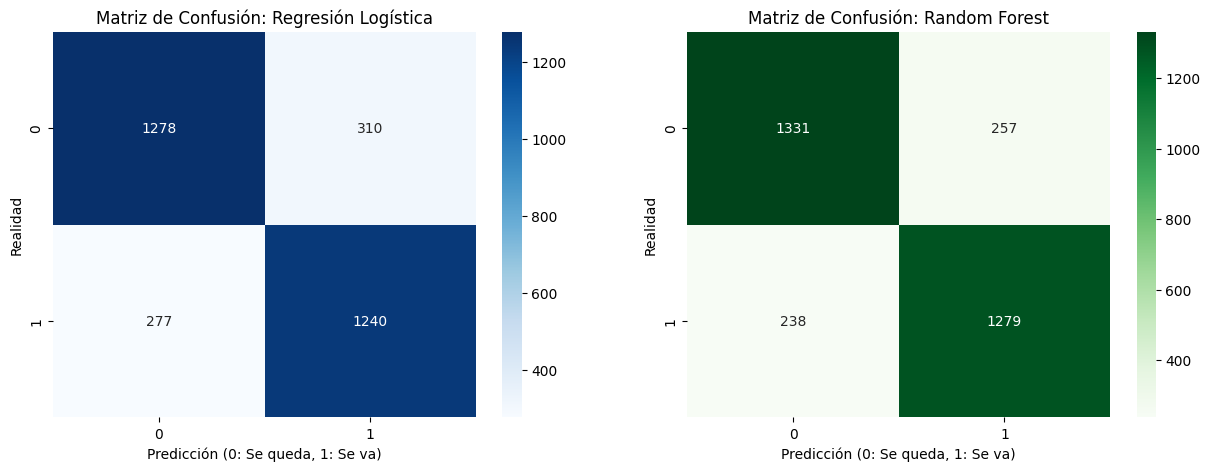

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

for i, (pred, name, color) in enumerate(zip([y_pred_log, y_pred_rf], ["Regresión Logística", "Random Forest"], ["Blues", "Greens"])):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=color, ax=ax[i])
    ax[i].set_title(f'Matriz de Confusión: {name}')
    ax[i].set_xlabel('Predicción (0: Se queda, 1: Se va)')
    ax[i].set_ylabel('Realidad')

plt.show()

In [29]:
print(f"Precisión Entrenamiento (RF): {modelo_rf.score(X_train, y_train):.4f}")
print(f"Precisión Prueba (RF): {modelo_rf.score(X_test, y_test):.4f}")

Precisión Entrenamiento (RF): 0.9988
Precisión Prueba (RF): 0.8406
